# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [1]:
# Imports
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Create connection to database
conn = sqlite3.connect('data.sqlite')

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type = 'table'", conn)

for table in tables['name']:
    row_count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", conn)['n'][0]
    columns = pd.read_sql(f"PRAGMA table_info({table})", conn)['name'].tolist()
    print(f"{table} ({row_count} rows): {columns}")

orderdetails (2996 rows): ['orderNumber', 'productCode', 'quantityOrdered', 'priceEach', 'orderLineNumber']
payments (273 rows): ['customerNumber', 'checkNumber', 'paymentDate', 'amount']
offices (7 rows): ['officeCode', 'city', 'phone', 'addressLine1', 'addressLine2', 'state', 'country', 'postalCode', 'territory']
customers (122 rows): ['customerNumber', 'customerName', 'contactLastName', 'contactFirstName', 'phone', 'addressLine1', 'addressLine2', 'city', 'state', 'postalCode', 'country', 'salesRepEmployeeNumber', 'creditLimit']
orders (326 rows): ['orderNumber', 'orderDate', 'requiredDate', 'shippedDate', 'status', 'comments', 'customerNumber']
productlines (7 rows): ['productLine', 'textDescription', 'htmlDescription', 'image']
products (110 rows): ['productCode', 'productName', 'productLine', 'productScale', 'productVendor', 'productDescription', 'quantityInStock', 'buyPrice', 'MSRP']
employees (23 rows): ['employeeNumber', 'lastName', 'firstName', 'extension', 'email', 'officeCod

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.
*Hint*: Make sure creditLimit is numeric.

In [2]:
ca_high_credit = pd.read_sql("""
SELECT customerNumber,
       customerName,
       contactFirstName,
       contactLastName,
       phone,
       city,
       state,
       CAST(creditLimit AS REAL) AS creditLimit
FROM customers
WHERE state = 'CA'
  AND CAST(creditLimit AS REAL) > 25000
ORDER BY creditLimit DESC;
""", conn)
ca_high_credit

,customerNumber,customerName,contactFirstName,contactLastName,phone,city,state,creditLimit
0,124,Mini Gifts Distributors Ltd.,Susan,Nelson,4155551450,San Rafael,CA,210500.0
1,239,Collectable Mini Designs Co.,Valarie,Thompson,7605558146,San Diego,CA,105000.0
2,321,Corporate Gift Ideas Co.,Julie,Brown,6505551386,San Francisco,CA,105000.0
3,205,Toys4GrownUps.com,Julie,Young,6265557265,Pasadena,CA,90700.0
4,161,Technics Stores Inc.,Juri,Hashimoto,6505556809,Burlingame,CA,84600.0
5,450,The Sharp Gifts Warehouse,Sue,Frick,4085553659,San Jose,CA,77600.0
6,129,Mini Wheels Co.,Julie,Murphy,6505555787,San Francisco,CA,64600.0
7,487,Signal Collectibles Ltd.,Sue,Taylor,4155554312,Brisbane,CA,60300.0
8,347,"Men 'R' US Retailers, Ltd.",Brian,Chandler,2155554369,Los Angeles,CA,57700.0
9,475,West Coast Collectables Co.,Steve,Thompson,3105553722,Burbank,CA,55400.0


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [3]:
intl_collect = pd.read_sql("""
SELECT customerNumber,
       customerName,
       contactFirstName,
       contactLastName,
       phone,
       city,
       country
FROM customers
WHERE country <> 'USA'
  AND customerName LIKE '%Collect%'
ORDER BY country, customerName;
""", conn)
intl_collect

,customerNumber,customerName,contactFirstName,contactLastName,phone,city,country
0,471,"Australian Collectables, Ltd",Sean,Clenahan,61-9-3844-6555,Glen Waverly,Australia
1,114,"Australian Collectors, Co.",Peter,Ferguson,03 9520 4555,Melbourne,Australia
2,382,Salzburg Collectables,Georg,Pipps,6562-9555,Salzburg,Austria
3,260,"Royal Canadian Collectables, Ltd.",Elizabeth,Lincoln,(604) 555-4555,Tsawassen,Canada
4,227,Heintze Collectables,Palle,Ibsen,86 21 3555,Århus,Denmark
5,353,Reims Collectables,Paul,Henriot,26.47.1555,Reims,France
6,415,"Bavarian Collectables Imports, Co.",Michael,Donnermeyer,+49 89 61 08 9555,Munich,Germany
7,409,Stuttgart Collectable Exchange,Rita,Müller,0711-555361,Stuttgart,Germany
8,211,"King Kong Collectables, Co.",Mike,Gao,+852 2251 1555,Central Hong Kong,Hong Kong
9,189,"Clover Collections, Co.",Dean,Cassidy,+353 1862 1555,Dublin,Ireland


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

The query uses this WHERE clause:

`WHERE country <> 'USA' AND customerName LIKE '%Collect%'`

The `<>` means "is not equal to," so the first condition keeps only customers whose country is not the USA.

The second condition checks to see if the word "Collect" appears anywhere in the name. `LIKE` searches for a pattern instead of an exact match, and the `%` means anything can come before or after.

The `AND` means both conditions must be true. Thus, neither a USA-based customer with "Collect" in their name, nor an international customer without it, would be included.

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [4]:
usa_state_credit = pd.read_sql("""
SELECT state,
       COUNT(*) AS numCustomers,
       ROUND(AVG(CAST(creditLimit AS REAL)), 2) AS avgCreditLimit
FROM customers
WHERE country = 'USA'
GROUP BY state
ORDER BY avgCreditLimit DESC;
""", conn)
usa_state_credit

,state,numCustomers,avgCreditLimit
0,NH,1,114200.00
1,NY,6,89966.67
2,PA,3,84766.67
3,CA,11,83854.55
4,NV,1,71800.00
5,MA,9,70755.56
6,CT,4,57350.00
7,NJ,1,43000.00


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

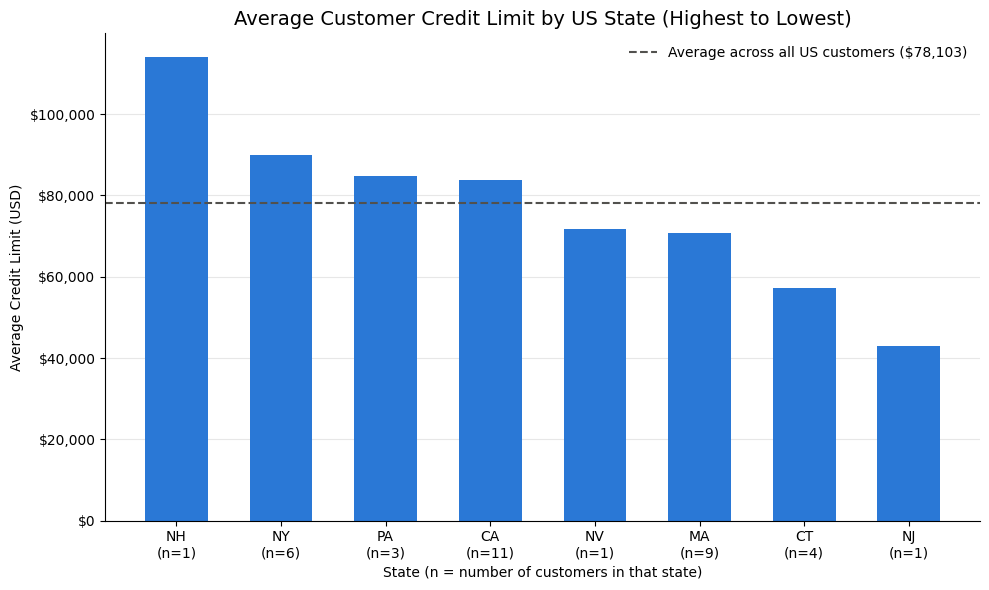

In [5]:
# Produce a visual to represent the average credit limit by state
us_avg = (usa_state_credit['avgCreditLimit'] * usa_state_credit['numCustomers']).sum() / usa_state_credit['numCustomers'].sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(usa_state_credit['state'], usa_state_credit['avgCreditLimit'], color='#2a78d6', width=0.6)
ax.axhline(us_avg, color='#52514e', linestyle='--', linewidth=1.5,
           label=f'Average across all US customers (${us_avg:,.0f})')

# Show how many customers each state's average is based on
ax.set_xticks(range(len(usa_state_credit)))
ax.set_xticklabels([f'{s}\n(n={n})' for s, n in zip(usa_state_credit['state'], usa_state_credit['numCustomers'])])

ax.set_title('Average Customer Credit Limit by US State (Highest to Lowest)', fontsize=14)
ax.set_xlabel('State (n = number of customers in that state)')
ax.set_ylabel('Average Credit Limit (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

**Note on Connecticut:** CT's $57,350 average includes one account, American Souvenirs Inc, with a
$0 credit limit and no orders or payments on record. Across CT's other three customers the average
is $76,467, which would rank CT 5th rather than 7th, so it is worth confirming that account's status
before treating CT as a state where credit policy is too conservative.

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [6]:
top_customers = pd.read_sql("""
SELECT c.customerNumber,
       c.customerName,
       ROUND(SUM(CAST(p.amount AS REAL)), 2) AS totalPayments
FROM customers AS c
JOIN payments AS p
  ON c.customerNumber = p.customerNumber
GROUP BY c.customerNumber, c.customerName
ORDER BY totalPayments DESC
LIMIT 10;
""", conn)
top_customers

,customerNumber,customerName,totalPayments
0,141,Euro+ Shopping Channel,715738.98
1,124,Mini Gifts Distributors Ltd.,584188.24
2,114,"Australian Collectors, Co.",180585.07
3,151,Muscle Machine Inc,177913.95
4,148,"Dragon Souveniers, Ltd.",156251.03
5,323,"Down Under Souveniers, Inc",154622.08
6,187,"AV Stores, Co.",148410.09
7,276,"Anna's Decorations, Ltd",137034.22
8,321,Corporate Gift Ideas Co.,132340.78
9,146,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

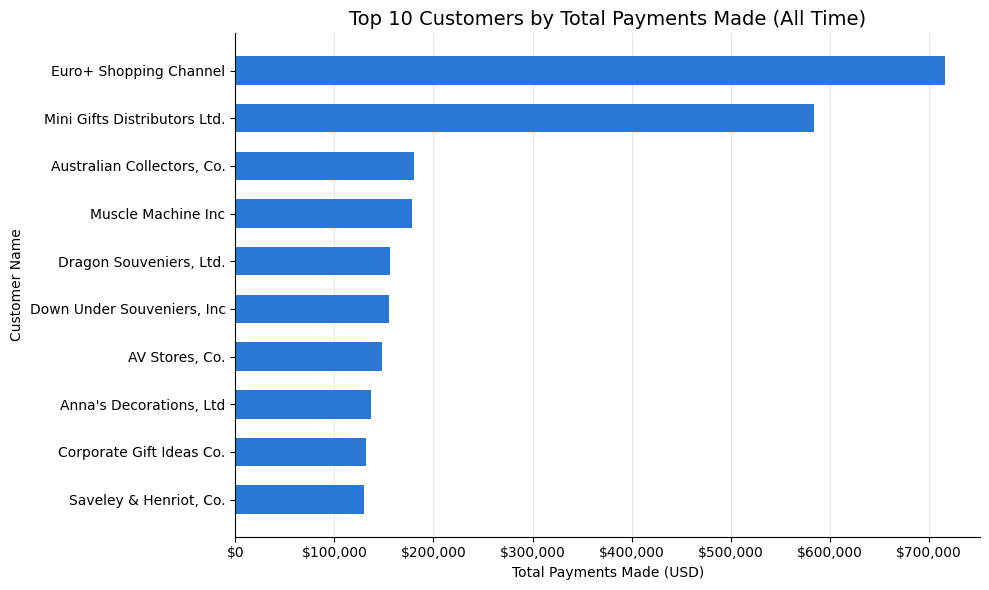

In [7]:
# Produce a visual to represent the top ten customers in terms of total payments
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_customers['customerName'], top_customers['totalPayments'], color='#2a78d6', height=0.6)
ax.invert_yaxis()  # largest total at the top

ax.set_title('Top 10 Customers by Total Payments Made (All Time)', fontsize=14)
ax.set_xlabel('Total Payments Made (USD)')
ax.set_ylabel('Customer Name')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [8]:
customer_product_qty = pd.read_sql("""
SELECT c.customerNumber,
       c.customerName,
       p.productCode,
       p.productName,
       SUM(CAST(od.quantityOrdered AS INTEGER)) AS totalQuantity
FROM customers AS c
JOIN orders AS o
  ON c.customerNumber = o.customerNumber
JOIN orderdetails AS od
  ON o.orderNumber = od.orderNumber
JOIN products AS p
  ON od.productCode = p.productCode
GROUP BY c.customerNumber, c.customerName, p.productCode, p.productName
HAVING SUM(CAST(od.quantityOrdered AS INTEGER)) >= 10
ORDER BY totalQuantity ASC;
""", conn)
customer_product_qty

,customerNumber,customerName,productCode,productName,totalQuantity
0,314,Petit Auto,S18_2949,1913 Ford Model T Speedster,10
1,412,"Extreme Desk Decorations, Ltd",S24_4620,1961 Chevrolet Impala,10
2,119,La Rochelle Gifts,S32_2509,1954 Greyhound Scenicruiser,11
3,328,Tekni Collectables Inc.,S700_1691,American Airlines: B767-300,11
4,450,The Sharp Gifts Warehouse,S24_3191,1969 Chevrolet Camaro Z28,13
...,...,...,...,...,...
2526,141,Euro+ Shopping Channel,S24_3432,2002 Chevy Corvette,174
2527,141,Euro+ Shopping Channel,S12_4473,1957 Chevy Pickup,183
2528,141,Euro+ Shopping Channel,S24_1444,1970 Dodge Coronet,197
2529,141,Euro+ Shopping Channel,S24_2840,1958 Chevy Corvette Limited Edition,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [9]:
product_line_summary = pd.read_sql("""
SELECT p.productLine,
       COUNT(DISTINCT p.productCode) AS numProducts,
       SUM(CAST(od.quantityOrdered AS INTEGER)) AS totalQuantityOrdered
FROM products AS p
LEFT JOIN orderdetails AS od
  ON p.productCode = od.productCode
GROUP BY p.productLine
ORDER BY totalQuantityOrdered DESC;
""", conn)
product_line_summary

,productLine,numProducts,totalQuantityOrdered
0,Classic Cars,38,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

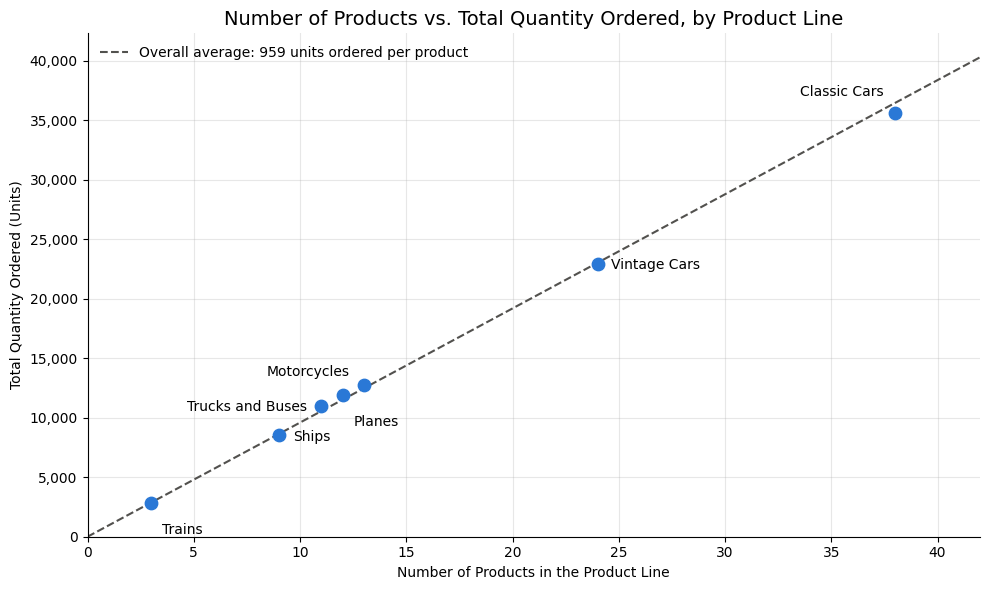

In [10]:
# Produce a visual to represent the relation between number of products and the total amount ordered
df = product_line_summary
units_per_product = df['totalQuantityOrdered'].sum() / df['numProducts'].sum()
x_max = df['numProducts'].max() + 4

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['numProducts'], df['totalQuantityOrdered'], s=80, color='#2a78d6', zorder=3)

# Reference line: total orders if every product sold the overall average
ax.plot([0, x_max], [0, units_per_product * x_max], color='#52514e', linestyle='--', linewidth=1.5,
        label=f'Overall average: {units_per_product:,.0f} units ordered per product')

# Label each dot with its product line (positions chosen so labels don't collide)
label_pos = {
    'Classic Cars':     dict(xytext=(-8, 10),  ha='right', va='bottom'),
    'Motorcycles':      dict(xytext=(-10, 6),  ha='right', va='baseline'),
    'Planes':           dict(xytext=(8, -14),  ha='left',  va='top'),
    'Trucks and Buses': dict(xytext=(-10, -4), ha='right', va='baseline'),
    'Trains':           dict(xytext=(8, -14),  ha='left',  va='top'),
}
default_pos = dict(xytext=(10, -4), ha='left', va='baseline')

for _, row in df.iterrows():
    ax.annotate(row['productLine'], (row['numProducts'], row['totalQuantityOrdered']),
                textcoords='offset points', fontsize=10,
                **label_pos.get(row['productLine'], default_pos))

ax.set_title('Number of Products vs. Total Quantity Ordered, by Product Line', fontsize=14)
ax.set_xlabel('Number of Products in the Product Line')
ax.set_ylabel('Total Quantity Ordered (Units)')
ax.set_xlim(0, x_max)
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

ax.grid(alpha=0.3)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

I used a scatter plot because the question is about a relationship between two numbers: how many products a product line has, and how many units customers ordered from it. Each dot is one product line, placed by those two numbers, so it's easy to see at a glance whether they rise together.

I also added a dashed line showing what each product line's total would be if every one of its products sold the overall average of 959 units. All seven dots fall almost exactly on this line.

This suggests that product lines with more products get more orders, in close proportion. Every product line sells roughly 936–1,000 units per product, so no line is significantly over- or under-performing for its size.

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [11]:
remote_office_employees = pd.read_sql("""
SELECT e.employeeNumber,
       e.firstName,
       e.lastName,
       e.jobTitle,
       e.email,
       e.extension,
       o.city AS officeCity,
       o.country AS officeCountry,
       s.firstName || ' ' || s.lastName AS supervisorName,
       s.jobTitle AS supervisorJobTitle
FROM employees AS e
JOIN offices AS o
  ON e.officeCode = o.officeCode
LEFT JOIN employees AS s
  ON e.reportsTo = s.employeeNumber
WHERE e.officeCode IN (
    SELECT officeCode
    FROM employees
    GROUP BY officeCode
    HAVING COUNT(*) < 5
)
ORDER BY officeCity, e.lastName;
""", conn)
remote_office_employees

,employeeNumber,firstName,lastName,jobTitle,email,extension,officeCity,officeCountry,supervisorName,supervisorJobTitle
0,1188,Julie,Firrelli,Sales Rep,jfirrelli@classicmodelcars.com,x2173,Boston,USA,Anthony Bow,Sales Manager (NA)
1,1216,Steve,Patterson,Sales Rep,spatterson@classicmodelcars.com,x4334,Boston,USA,Anthony Bow,Sales Manager (NA)
2,1501,Larry,Bott,Sales Rep,lbott@classicmodelcars.com,x2311,London,UK,Gerard Bondur,Sale Manager (EMEA)
3,1504,Barry,Jones,Sales Rep,bjones@classicmodelcars.com,x102,London,UK,Gerard Bondur,Sale Manager (EMEA)
4,1286,Foon Yue,Tseng,Sales Rep,ftseng@classicmodelcars.com,x2248,NYC,USA,Anthony Bow,Sales Manager (NA)
5,1323,George,Vanauf,Sales Rep,gvanauf@classicmodelcars.com,x4102,NYC,USA,Anthony Bow,Sales Manager (NA)
6,1611,Andy,Fixter,Sales Rep,afixter@classicmodelcars.com,x101,Sydney,Australia,William Patterson,Sales Manager (APAC)
7,1619,Tom,King,Sales Rep,tking@classicmodelcars.com,x103,Sydney,Australia,William Patterson,Sales Manager (APAC)
8,1612,Peter,Marsh,Sales Rep,pmarsh@classicmodelcars.com,x102,Sydney,Australia,William Patterson,Sales Manager (APAC)
9,1088,William,Patterson,Sales Manager (APAC),wpatterson@classicmodelcars.com,x4871,Sydney,Australia,Mary Patterson,VP Sales


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

The request has two parts: first find the offices with fewer than 5 employees, then return the employees who work in those offices. That told me the subquery should handle the first part and the main query the second.

**The subquery** finds the qualifying offices:

    SELECT officeCode
    FROM employees
    GROUP BY officeCode
    HAVING COUNT(*) < 5

It groups the employees table by `officeCode` and counts the employees in each group. The condition is on a count, which only exists after grouping, so it has to go in `HAVING` rather than `WHERE`. The result is a single column of office codes: Boston, NYC, London, Tokyo and Sydney. Paris has exactly 5 employees, so it's correctly excluded.

**The main query** then uses `WHERE e.officeCode IN (...)` to keep only employees whose office code appears in that list. Because the subquery returns just one column, `IN` can check each employee's office against it directly.

I used a subquery instead of adding `GROUP BY` and `HAVING` to the main query because the main query needs one row per employee, not one row per office. Grouping the main query would collapse the employees into office counts. Keeping the count in the subquery lets the main query stay at the employee level, where it can join `offices` for the location and join `employees` to itself on `reportsTo` to get each person's supervisor.

The result is 12 employees across 5 offices.


### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [12]:
conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [13]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

### Step 1: Initial Exploration

Before asking a business question I want to know what is actually in this database: how big each
table is, what years it covers, how complete the fields are, and how much of the ratings data can be
trusted. The queries below build that picture one question at a time.

In [14]:
# Table sizes and columns
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type = 'table'", conn4)

for table in tables['name']:
    row_count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table}", conn4)['n'][0]
    columns = pd.read_sql(f"PRAGMA table_info({table})", conn4)['name'].tolist()
    print(f"{table} ({row_count:,} rows): {columns}")

movie_basics (146,144 rows): ['movie_id', 'primary_title', 'original_title', 'start_year', 'runtime_minutes', 'genres']
directors (291,174 rows): ['movie_id', 'person_id']
known_for (1,638,260 rows): ['person_id', 'movie_id']
movie_akas (331,703 rows): ['movie_id', 'ordering', 'title', 'region', 'language', 'types', 'attributes', 'is_original_title']
movie_ratings (73,856 rows): ['movie_id', 'averagerating', 'numvotes']
persons (606,648 rows): ['person_id', 'primary_name', 'birth_year', 'death_year', 'primary_profession']
principals (1,028,186 rows): ['movie_id', 'ordering', 'person_id', 'category', 'job', 'characters']
writers (255,873 rows): ['movie_id', 'person_id']


In [15]:
# Titles per release year - intentionally unfiltered, to expose post-2019 and impossible years
year_coverage = pd.read_sql("""
SELECT start_year,
       COUNT(*) AS numTitles
FROM movie_basics
GROUP BY start_year
ORDER BY start_year;
""", conn4)
year_coverage

,start_year,numTitles
0,2010,11849
1,2011,12900
2,2012,13787
3,2013,14709
4,2014,15589
5,2015,16243
6,2016,17272
7,2017,17504
8,2018,16849
9,2019,8379


In [16]:
# Null audit for 2010-2019 - this cell counts nulls; the analysis cells below exclude them
data_quality = pd.read_sql("""
SELECT COUNT(*) AS totalMovies,
       SUM(CASE WHEN b.genres IS NULL THEN 1 ELSE 0 END) AS nullGenres,
       SUM(CASE WHEN b.runtime_minutes IS NULL THEN 1 ELSE 0 END) AS nullRuntime,
       SUM(CASE WHEN b.primary_title <> b.original_title THEN 1 ELSE 0 END) AS titleMismatch,
       SUM(CASE WHEN r.movie_id IS NULL THEN 1 ELSE 0 END) AS noRating,
       ROUND(100.0 * SUM(CASE WHEN r.movie_id IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS pctRated
FROM movie_basics AS b
LEFT JOIN movie_ratings AS r
  ON b.movie_id = r.movie_id
WHERE b.start_year BETWEEN 2010 AND 2019;
""", conn4)
data_quality

,totalMovies,nullGenres,nullRuntime,titleMismatch,noRating,pctRated
0,145081,5359,30765,14456,71225,50.9


In [17]:
# How reliable is an average rating? Depends entirely on how many votes back it.
# Scoped to the 2010-2019 window, with null ratings and vote counts excluded explicitly.
vote_distribution = pd.read_sql("""
SELECT COUNT(*) AS ratedMovies,
       MIN(r.numvotes) AS minVotes,
       MAX(r.numvotes) AS maxVotes,
       SUM(CASE WHEN r.numvotes < 10 THEN 1 ELSE 0 END) AS under10Votes,
       SUM(CASE WHEN r.numvotes < 100 THEN 1 ELSE 0 END) AS under100Votes,
       SUM(CASE WHEN r.numvotes < 1000 THEN 1 ELSE 0 END) AS under1000Votes,
       ROUND(AVG(r.averagerating), 2) AS avgRatingAll,
       ROUND(AVG(CASE WHEN r.numvotes >= 1000 THEN r.averagerating END), 2) AS avgRating1000Plus
FROM movie_ratings AS r
JOIN movie_basics AS b
  ON r.movie_id = b.movie_id
WHERE b.start_year BETWEEN 2010 AND 2019
  AND r.averagerating IS NOT NULL
  AND r.numvotes IS NOT NULL;
""", conn4)
vote_distribution

,ratedMovies,minVotes,maxVotes,under10Votes,under100Votes,under1000Votes,avgRatingAll,avgRating1000Plus
0,73856,5,1841066,12146,45103,64239,6.33,6.25


In [18]:
# Shape of the genres column - the reason it can't be grouped directly.
# Null genres excluded per the exploration brief.
genre_shape = pd.read_sql("""
SELECT COUNT(DISTINCT genres) AS genreCombos,
       MAX(LENGTH(genres) - LENGTH(REPLACE(genres, ',', '')) + 1) AS maxGenresListed
FROM movie_basics
WHERE genres IS NOT NULL
  AND start_year BETWEEN 2010 AND 2019;
""", conn4)
genre_shape

,genreCombos,maxGenresListed
0,1084,3


In [19]:
# Runtime outliers and duplicate title/year pairs, 2010-2019 (null runtimes excluded)
integrity_checks = pd.read_sql("""
SELECT MIN(runtime_minutes) AS minRuntime,
       MAX(runtime_minutes) AS maxRuntime,
       SUM(CASE WHEN runtime_minutes < 40 THEN 1 ELSE 0 END) AS under40Min,
       SUM(CASE WHEN runtime_minutes > 240 THEN 1 ELSE 0 END) AS over240Min,
       (SELECT COUNT(*)
        FROM (SELECT primary_title, start_year
              FROM movie_basics
              WHERE start_year BETWEEN 2010 AND 2019
              GROUP BY primary_title, start_year
              HAVING COUNT(*) > 1)) AS duplicateTitleYearPairs
FROM movie_basics
WHERE start_year BETWEEN 2010 AND 2019
  AND runtime_minutes IS NOT NULL;
""", conn4)
integrity_checks

,minRuntime,maxRuntime,under40Min,over240Min,duplicateTitleYearPairs
0,1.0,51420.0,5209,207,1859


### Initial Exploration Findings

- **Scope.** 146,144 titles overall, 145,081 of them released 2010–2019. Output grew steadily from
  11,849 titles in 2010 to a peak of 17,504 in 2017.
- **The year field needs filtering.** 1,063 titles are dated after 2019, including one with a
  `start_year` of **2115**. 2019 shows only 8,379 titles against 16,849 in 2018, which is consistent
  with a snapshot taken partway through 2019 rather than a real drop in production.
- **Ratings cover only half the catalog.** Just **50.9%** of in-range titles have a rating; 71,225
  have none. Anything computed from ratings describes rated titles only.
- **Most ratings are too thin to trust.** Of the 73,856 rated titles, 12,146 rest on fewer than 10
  votes and 45,103 on fewer than 100; vote counts range from 5 to 1,841,066. I use a **1,000-vote
  floor** throughout to separate "a real audience saw this" from noise.
- **`genres` can't be grouped as-is.** It packs up to 3 genres into one comma-separated string,
  giving 1,084 distinct combinations in range.
- **Nulls are concentrated in runtime.** 30,765 titles have no `runtime_minutes` and 5,359 have no
  `genres`. These rows are excluded from analysis, never filled in.
- **Runtimes and titles have integrity problems.** Non-null runtimes run from 1 to 51,420 minutes
  (about 36 days), with 5,209 titles under 40 minutes and 207 over 4 hours. 1,859 title-and-year
  pairs appear more than once.

### Step 2: Genre and Runtime Analysis

Genre is the most basic choice a studio makes about a film, so I compared how many titles each genre
produced against how often its rated titles reached a real audience (1,000+ votes) and how well those
titles were reviewed. Runtime is a secondary check on the same two outcomes.

In [20]:
# Supply vs. audience reach by genre, 2010-2019.
# genres is a comma-separated string, so each genre is matched with a comma-wrapped LIKE
# (a bare '%Music%' would also match 'Musical'). Null genres are excluded, and unrated
# titles are left out of pctOfRated and avgRating.
genre_supply_demand = pd.read_sql("""
WITH genre_list(genre) AS (
    VALUES ('Documentary'),('Drama'),('Comedy'),('Thriller'),('Horror'),('Action'),
           ('Romance'),('Biography'),('Crime'),('Adventure'),('Family'),('History'),
           ('Mystery'),('Music'),('Fantasy'),('Sci-Fi'),('Animation'),('Sport'),
           ('War'),('Musical')
)
SELECT g.genre,
       COUNT(*) AS titlesProduced,
       SUM(CASE WHEN r.movie_id IS NOT NULL THEN 1 ELSE 0 END) AS titlesRated,
       SUM(CASE WHEN r.numvotes >= 1000 THEN 1 ELSE 0 END) AS titlesWithAudience,
       ROUND(100.0 * SUM(CASE WHEN r.numvotes >= 1000 THEN 1 ELSE 0 END)
             / SUM(CASE WHEN r.movie_id IS NOT NULL THEN 1 ELSE 0 END), 1) AS pctOfRated,
       ROUND(AVG(CASE WHEN r.numvotes >= 1000 THEN r.averagerating END), 2) AS avgRating
FROM genre_list AS g
JOIN movie_basics AS b
  ON ',' || b.genres || ',' LIKE '%,' || g.genre || ',%'
LEFT JOIN movie_ratings AS r
  ON b.movie_id = r.movie_id
WHERE b.start_year BETWEEN 2010 AND 2019
  AND b.genres IS NOT NULL
GROUP BY g.genre
ORDER BY titlesProduced DESC;
""", conn4)
genre_supply_demand

,genre,titlesProduced,titlesRated,titlesWithAudience,pctOfRated,avgRating
0,Documentary,51556,17753,741,4.2,7.27
1,Drama,49545,30788,5047,16.4,6.49
2,Comedy,25127,17290,3005,17.4,6.11
3,Thriller,11746,8217,1797,21.9,5.90
4,Horror,10692,7674,1315,17.1,5.28
5,Action,10156,6988,1998,28.6,6.01
6,Romance,9327,6589,1351,20.5,6.34
7,Biography,8695,3809,701,18.4,6.96
8,Crime,6691,4611,1318,28.6,6.27
9,Adventure,6366,3817,1002,26.3,6.16


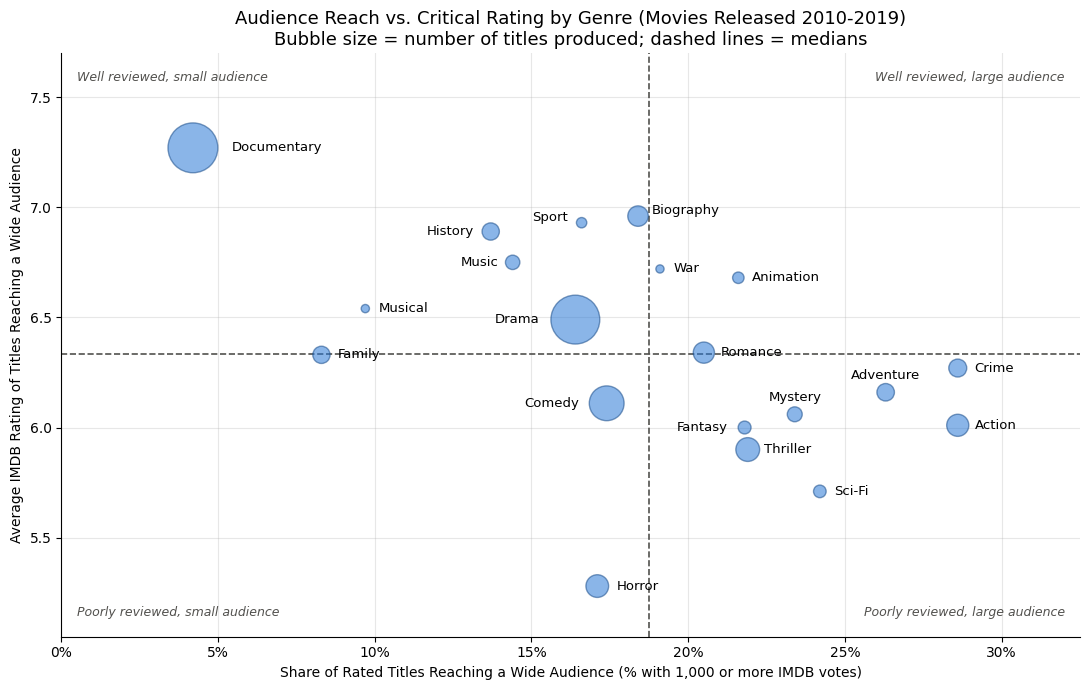

In [21]:
# Quadrant scatter: audience reach vs. rating by genre; bubble size = titles produced
df = genre_supply_demand
x_mid = df['pctOfRated'].median()
y_mid = df['avgRating'].median()

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(df['pctOfRated'], df['avgRating'],
           s=df['titlesProduced'] / 40, color='#2a78d6', alpha=0.55,
           edgecolors='#1a4d8a', linewidths=1, zorder=3)

ax.axvline(x_mid, color='#52514e', linestyle='--', linewidth=1.2, zorder=2)
ax.axhline(y_mid, color='#52514e', linestyle='--', linewidth=1.2, zorder=2)

# Label offsets in points, chosen so no two labels collide
label_pos = {
    'Documentary': (28, 0), 'Drama': (-26, 0), 'Comedy': (-20, 0),
    'Thriller': (12, 0), 'Horror': (14, 0), 'Action': (12, 0),
    'Romance': (12, 0), 'Biography': (10, 4), 'Crime': (12, 0),
    'Adventure': (0, 12), 'History': (-12, 0), 'Family': (12, 0),
    'Mystery': (0, 12), 'Music': (-10, 0), 'Fantasy': (-12, 0),
    'Sci-Fi': (10, 0), 'Animation': (10, 0), 'Sport': (-10, 4),
    'Musical': (10, 0), 'War': (10, 0),
}
for _, row in df.iterrows():
    dx, dy = label_pos[row['genre']]
    ax.annotate(row['genre'], (row['pctOfRated'], row['avgRating']),
                textcoords='offset points', xytext=(dx, dy),
                ha='right' if dx < 0 else ('center' if dx == 0 else 'left'),
                va='center', fontsize=9.5)

for x, y, text in [(0.015, 0.97, 'Well reviewed, small audience'),
                   (0.985, 0.97, 'Well reviewed, large audience'),
                   (0.015, 0.03, 'Poorly reviewed, small audience'),
                   (0.985, 0.03, 'Poorly reviewed, large audience')]:
    ax.text(x, y, text, transform=ax.transAxes, fontsize=9, style='italic', color='#52514e',
            ha='left' if x < 0.5 else 'right', va='top' if y > 0.5 else 'bottom')

ax.set_title('Audience Reach vs. Critical Rating by Genre (Movies Released 2010-2019)\n'
             'Bubble size = number of titles produced; dashed lines = medians', fontsize=13)
ax.set_xlabel('Share of Rated Titles Reaching a Wide Audience (% with 1,000 or more IMDB votes)')
ax.set_ylabel('Average IMDB Rating of Titles Reaching a Wide Audience')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_xlim(0, 32.5)
ax.set_ylim(5.05, 7.7)

ax.grid(alpha=0.3)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
# Supporting angle: does runtime relate to rating and audience size?
# Runtime is filtered to a plausible 40-240 min band - see the cleaning tasks below.
runtime_bands = pd.read_sql("""
SELECT CASE
         WHEN b.runtime_minutes < 80  THEN '1. Under 80 min'
         WHEN b.runtime_minutes < 100 THEN '2. 80-99 min'
         WHEN b.runtime_minutes < 120 THEN '3. 100-119 min'
         WHEN b.runtime_minutes < 150 THEN '4. 120-149 min'
         ELSE '5. 150+ min'
       END AS runtimeBand,
       COUNT(*) AS numMovies,
       ROUND(AVG(r.averagerating), 2) AS avgRating,
       ROUND(AVG(r.numvotes), 0) AS avgVotes
FROM movie_basics AS b
JOIN movie_ratings AS r
  ON b.movie_id = r.movie_id
WHERE b.start_year BETWEEN 2010 AND 2019
  AND b.runtime_minutes IS NOT NULL
  AND b.runtime_minutes BETWEEN 40 AND 240
  AND r.numvotes >= 1000
GROUP BY runtimeBand
ORDER BY runtimeBand;
""", conn4)
runtime_bands

,runtimeBand,numMovies,avgRating,avgVotes
0,1. Under 80 min,293,6.20,3424.0
1,2. 80-99 min,4188,5.85,13141.0
2,3. 100-119 min,3129,6.44,31964.0
3,4. 120-149 min,1582,6.76,50361.0
4,5. 150+ min,411,6.97,40570.0


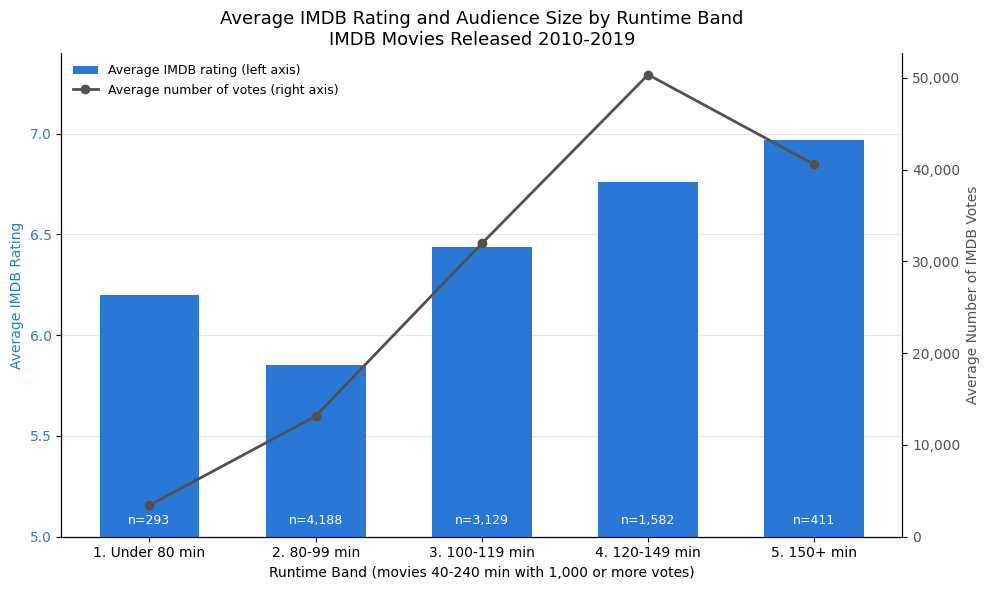

In [23]:
# Two different units (rating vs. votes), so two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(runtime_bands['runtimeBand'], runtime_bands['avgRating'],
               color='#2a78d6', width=0.6, zorder=3, label='Average IMDB rating (left axis)')
ax1.set_ylim(5.0, 7.4)
ax1.set_ylabel('Average IMDB Rating', color='#2a78d6')
ax1.tick_params(axis='y', labelcolor='#2a78d6')
ax1.set_xlabel('Runtime Band (movies 40-240 min with 1,000 or more votes)')

ax2 = ax1.twinx()
ax2.plot(runtime_bands['runtimeBand'], runtime_bands['avgVotes'],
         color='#52514e', marker='o', linewidth=2, zorder=4,
         label='Average number of votes (right axis)')
ax2.set_ylabel('Average Number of IMDB Votes', color='#52514e')
ax2.tick_params(axis='y', labelcolor='#52514e')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax2.set_ylim(0, None)

for bar, n in zip(bars, runtime_bands['numMovies']):
    ax1.text(bar.get_x() + bar.get_width() / 2, 5.05, f'n={n:,}',
             ha='center', va='bottom', fontsize=9, color='white', zorder=5)

ax1.set_title('Average IMDB Rating and Audience Size by Runtime Band\n'
              'IMDB Movies Released 2010-2019', fontsize=13)
ax1.grid(axis='y', alpha=0.3)
ax1.set_axisbelow(True)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

### Business Question

**The pattern.** The genre table and quadrant chart show that what gets made and what gets watched
point in opposite directions:

- **Documentary** is the most-produced genre (51,556 titles) and the highest-rated (7.27), yet only
  **4.2%** of rated documentaries reach 1,000 votes, the lowest rate of any genre.
- **Drama**, the second-largest genre (49,545 titles), reaches an audience 16.4% of the time, below
  the 18.75% median.
- **Action and Crime** reach an audience **28.6%** of the time, nearly seven times Documentary's rate,
  on a fraction of its volume (10,156 and 6,691 titles), at ratings of 6.01 and 6.27.
- Only three genres sit above the median on both reach and rating: **War, Animation, and Romance**
  (Romance only just, at 6.34 against a 6.335 median). Crime has the joint-highest reach and sits
  just below the rating median.
- **Runtime** adds a second signal. The 80–99 minute band is the most common length (4,188 of the
  9,603 titles in the runtime analysis) and has the lowest average rating (5.85). From there, rating
  rises with every band to 6.97 at 150+ minutes, and average audience size peaks at 120–149 minutes
  (50,361 votes).

> **Question for deeper analysis:** The genres produced most are the least likely to find an
> audience. Which combinations of genre and runtime give a new title the best chance of reaching a
> wide audience without sacrificing its rating, and in which genres is production outrunning demand?

**What answering it would require.** This database has no budget or revenue, so vote count stands in
for audience reach and says nothing about profit. A deeper analysis would join budget and box-office
data, and examine genre and runtime together rather than one at a time.

### Potential Data Cleaning Tasks

Identified during exploration; per the brief, listed rather than performed. The cell each figure
comes from is noted in parentheses.

1. **Restrict release years to 2010–2019.** 1,063 titles are dated later, one of them 2115
   (`year_coverage`).
2. **Label 2019 as a partial year.** It has 8,379 titles against 16,849 in 2018, so year-over-year
   trends should stop at 2018 or flag 2019 (`year_coverage`).
3. **Normalize `genres` into a bridge table.** There are 1,084 comma-separated combinations with up
   to 3 genres each (`genre_shape`). A `movie_genres` (`movie_id`, `genre`) table would allow direct
   grouping; the comma-wrapped `LIKE` used here is a workaround.
4. **Exclude nulls rather than impute them.** 30,765 titles lack `runtime_minutes` and 5,359 lack
   `genres` (`data_quality`).
5. **Label rating-based results as covering rated titles only.** Only 50.9% of in-range titles have
   a rating (`data_quality`), and the unrated half is likely the more obscure half.
6. **Set and state a minimum-vote threshold.** Vote counts run from 5 to 1,841,066, and 12,146
   titles have fewer than 10 votes (`vote_distribution`). This analysis uses 1,000.
7. **Bound runtimes to a plausible range.** Values run from 1 to 51,420 minutes; 5,209 titles are
   under 40 minutes and 207 are over 240 (`integrity_checks`).
8. **Review duplicate titles.** 1,859 title-and-year pairs occur more than once; some are remakes,
   some are likely duplicate entries (`integrity_checks`).
9. **Standardize title fields.** 14,456 in-range titles have a `primary_title` that differs from
   `original_title` (`data_quality`). Pick one field for joins and one for display.
10. **Enforce key integrity.** No primary or foreign keys are declared on `movie_id` or `person_id`
    (see the schema above), so link tables such as `directors` and `principals` can reference titles
    missing from `movie_basics`.

In [24]:
# Close the connection to im.db
conn4.close()

### Reflection

**The vote threshold was the biggest judgment call.** Requiring 1,000 votes sets aside 64,239 of the
73,856 rated titles (`vote_distribution`), leaving 9,617. I accepted that because a rating from five
voters says almost nothing about how a film landed with audiences. The overall average barely moves
(6.33 to 6.25), so the floor changes *which* titles count far more than it changes the average.

**Reach is measured against rated titles, not all titles.** The brief asks for nulls to be excluded,
so `pctOfRated` uses rated titles as its denominator. Counting unrated titles as reaching no audience
would lower every genre's rate and widen the gap between Documentary and Action, so this choice
understates the headline finding rather than inflating it.

**Genre overlap limits what this can prove.** A title with three genres is counted in all three
rows, so `titlesProduced` sums to 225,782 against 145,081 titles in range. Documentary and Drama
overlap, so their effects can't be fully separated, and nothing here shows that genre *causes*
reach: wide theatrical release, for example, likely favors Action over Documentary regardless of
quality. A normalized genre table and budget or release data would be the next step.